# Import Library

In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [ ]:
# Pilihan:
# 0 = Full Dataset
# 1 = 10k
# 2 = 20k
# 3 = 30k
# 4 = 40k

CORPUS_SIZE = 1

if CORPUS_SIZE == 0:
    DATASET_NAME = "full"
elif CORPUS_SIZE == 1:
    DATASET_NAME = "10k"
elif CORPUS_SIZE == 2:
    DATASET_NAME = "20k"
elif CORPUS_SIZE == 3:
    DATASET_NAME = "30k"
elif CORPUS_SIZE == 4:
    DATASET_NAME = "40k"
else:
    raise ValueError(
        "CORPUS_SIZE harus 0, 1, 2, 3, atau 4"
    )

DATA_DIR = Path(
    f"dataset/preprocessed/{DATASET_NAME}"
)

print(f"Corpus : {DATASET_NAME}")
print(f"Path   : {DATA_DIR}")

# Load Dataset & Label Encoder

Dataset

In [ ]:
X_train = pd.read_csv(f"dataset/preprocessed/{CORPUS_SIZE}/X_train.csv").squeeze()
X_test = pd.read_csv(f"dataset/preprocessed//{CORPUS_SIZE}/X_test.csv").squeeze()

y_train = pd.read_csv(f"dataset/preprocessed//{CORPUS_SIZE}/y_train.csv").squeeze()
y_test = pd.read_csv(f"dataset/preprocessed//{CORPUS_SIZE}/y_test.csv").squeeze()

Label Encoder

In [ ]:
le = joblib.load("dataset/preprocessed/label_encoder.pkl")
class_names = list(le.classes_)

print(class_names)

['Economy', 'Entertainment', 'Technology']


# Vectorization

In [4]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(38963, 160673)
(9741, 160673)


In [ ]:
os.makedirs("vectorizers/skenario 2", exist_ok=True)

joblib.dump(
    tfidf, 
    f"vectorizers/skenario 2/tfidf_vectorizer_{CORPUS_SIZE}.joblib"
)

['vectorizers/tfidf_vectorizer.joblib']

# Modeling

Training

In [6]:
svm_model = SVC(
    kernel="linear",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

SVC(kernel='linear', probability=True, random_state=42)

Predict

In [7]:
y_pred = svm_model.predict(X_test_tfidf)

In [ ]:
os.makedirs("models/skenario 2", exist_ok=True)

joblib.dump(svm_model, f"models/skenario 2/tfidf_svm_{CORPUS_SIZE}.joblib")

['models/tfidf_svm.joblib']

# Evaluation

## Classification Report

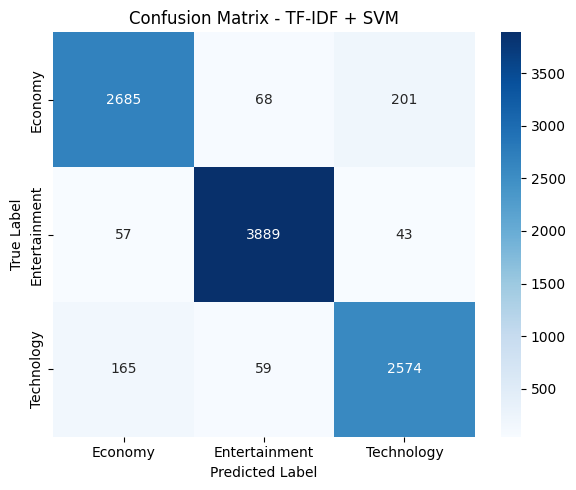

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - TF-IDF + SVM"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Confussion Matrix

In [10]:
print("\n=== Classification Report ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


=== Classification Report ===

               precision    recall  f1-score   support

      Economy       0.92      0.91      0.92      2954
Entertainment       0.97      0.97      0.97      3989
   Technology       0.91      0.92      0.92      2798

     accuracy                           0.94      9741
    macro avg       0.94      0.93      0.93      9741
 weighted avg       0.94      0.94      0.94      9741



## Overall

In [11]:
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n=== TF-IDF + Naive Bayes ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


=== TF-IDF + Naive Bayes ===
Accuracy : 0.9391
Precision: 0.9351
Recall   : 0.9346
F1-Score : 0.9348


In [12]:
result = pd.DataFrame([
    {
        "Train_Size": len(X_train),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
])

In [13]:
result

,Train_Size,Accuracy,Precision,Recall,F1-Score
0,38963,0.939123,0.935141,0.934604,0.934845


In [ ]:
os.makedirs("results/traning", exist_ok=True)
RESULT_FILE = "results/traning/tfidf_svm_results.csv"

if os.path.exists(RESULT_FILE):
    previous = pd.read_csv(RESULT_FILE)

    result = pd.concat(
        [previous, result],
        ignore_index=True
    )

    # jika train size sama,
    # simpan hasil terbaru

    result = result.drop_duplicates(
        subset=["Train_Size"],
        keep="last"
    )

result = result.sort_values(by="Train_Size")
result.to_csv(RESULT_FILE, index=False)
